## t-SNE on the full MNIST dataset

In [1]:
%pip install pandas numpy scikit-learn matplotlib kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print(sys.executable)

c:\Users\ariel\OneDrive\CUCEI\5to\Algorithm Analysis\Activities\04_tsne\.venv\Scripts\python.exe


In [3]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "mnist_train.csv"))

y = df["label"]
X = df.drop(columns="label")
print(X.shape, y.shape)

c:\Users\ariel\OneDrive\CUCEI\5to\Algorithm Analysis\Activities\04_tsne\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 15.2M/15.2M [00:01<00:00, 11.2MB/s]

Extracting files...


Files: ['mnist_test.csv', 'mnist_train.csv']
(60000, 784) (60000,)


In [5]:
from sklearn.decomposition import PCA

X_scaled = X / 255.0
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape, pca.explained_variance_ratio_.sum())

(60000, 50) 0.8246468633334725


In [6]:
from sklearn.manifold import TSNE
import numpy as np
import time

start = time.time()
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, verbose=1)
X_tsne = tsne.fit_transform(X_pca)
print(f"Done in {(time.time() - start) / 60:.1f} minutes")

np.save("X_tsne.npy", X_tsne)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 60000 samples in 0.003s...
[t-SNE] Computed neighbors for 60000 samples in 5.436s...
[t-SNE] Computed conditional probabilities for sample 1000 / 60000
[t-SNE] Computed conditional probabilities for sample 2000 / 60000
[t-SNE] Computed conditional probabilities for sample 3000 / 60000
[t-SNE] Computed conditional probabilities for sample 4000 / 60000
[t-SNE] Computed conditional probabilities for sample 5000 / 60000
[t-SNE] Computed conditional probabilities for sample 6000 / 60000
[t-SNE] Computed conditional probabilities for sample 7000 / 60000
[t-SNE] Computed conditional probabilities for sample 8000 / 60000
[t-SNE] Computed conditional probabilities for sample 9000 / 60000
[t-SNE] Computed conditional probabilities for sample 10000 / 60000
[t-SNE] Computed conditional probabilities for sample 11000 / 60000
[t-SNE] Computed conditional probabilities for sample 12000 / 60000
[t-SNE] Computed conditional probabilities for sam

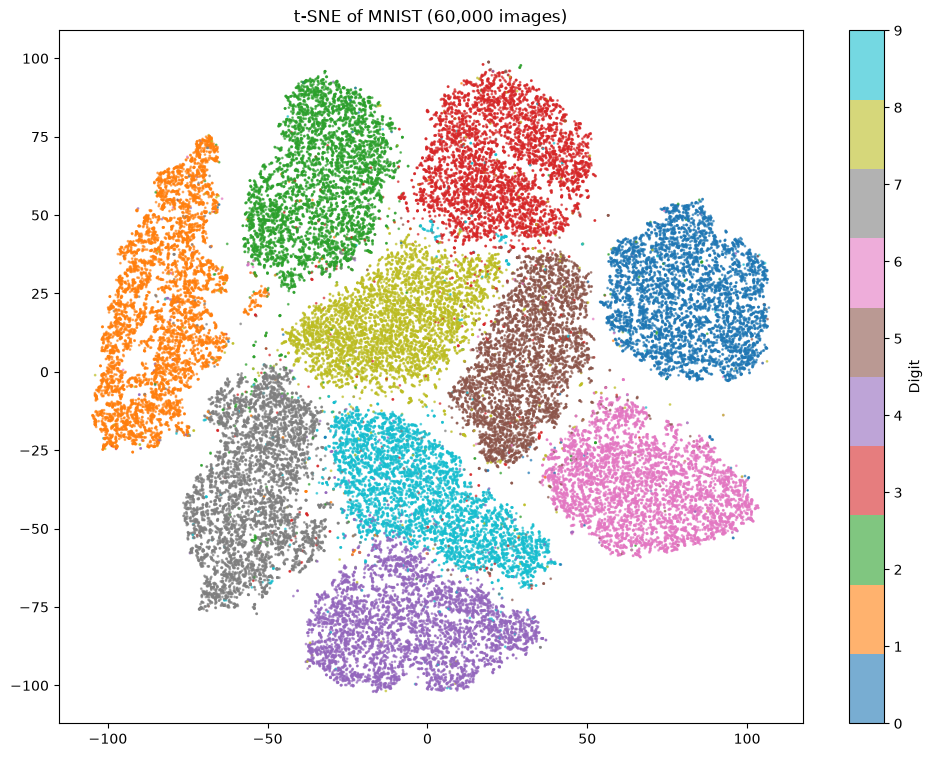

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=1, alpha=0.6)
plt.colorbar(sc, ticks=range(10), label="Digit")
plt.title("t-SNE of MNIST (60,000 images)")
plt.show()

## t-SNE of digit 7 only

In [10]:
mask = (y == 7)
X_7_scaled = X_scaled[mask]
pca_7 = PCA(n_components=50, random_state=42)
X_7_pca = pca_7.fit_transform(X_7_scaled)
print(X_7_pca.shape, pca_7.explained_variance_ratio_.sum())

(6265, 50) 0.8710528325640708


In [13]:
start = time.time()
tsne_7 = TSNE(n_components=2, random_state=42, n_jobs=-1, verbose=1)
X_7_tsne = tsne_7.fit_transform(X_7_pca)
print(f"Done in {(time.time() - start) / 60:.1f} minutes")

np.save("X_7_tsne.npy", X_7_tsne)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6265 samples in 0.001s...
[t-SNE] Computed neighbors for 6265 samples in 0.072s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6265
[t-SNE] Computed conditional probabilities for sample 2000 / 6265
[t-SNE] Computed conditional probabilities for sample 3000 / 6265
[t-SNE] Computed conditional probabilities for sample 4000 / 6265
[t-SNE] Computed conditional probabilities for sample 5000 / 6265
[t-SNE] Computed conditional probabilities for sample 6000 / 6265
[t-SNE] Computed conditional probabilities for sample 6265 / 6265
[t-SNE] Mean sigma: 1.597517
[t-SNE] KL divergence after 250 iterations with early exaggeration: 85.117844
[t-SNE] KL divergence after 1000 iterations: 1.990552
Done in 0.2 minutes


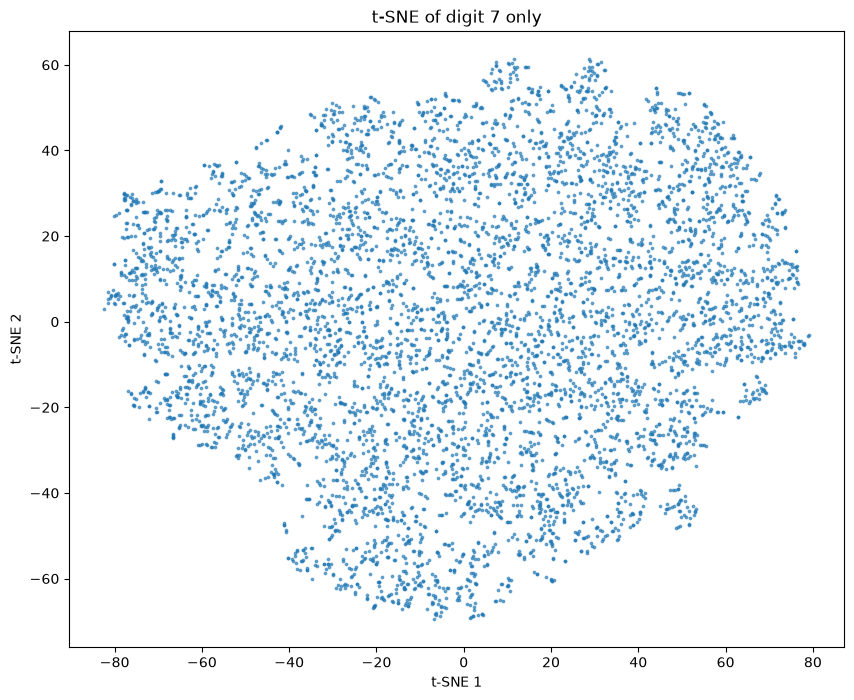

In [16]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(X_7_tsne[:, 0], X_7_tsne[:, 1], color="tab:blue", s=3, alpha=0.6)
plt.title("t-SNE of digit 7 only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### KMeans

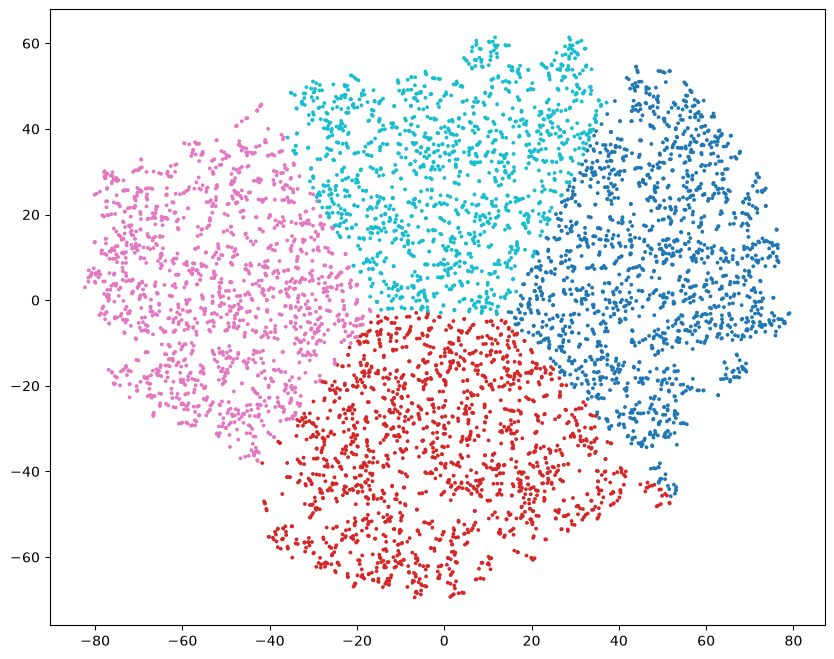

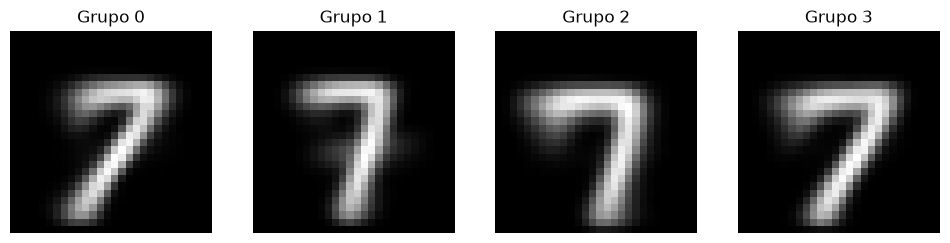

In [30]:
from sklearn.cluster import KMeans
k = 4

labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_7_tsne)

plt.figure(figsize=(10, 8))
plt.scatter(X_7_tsne[:, 0], X_7_tsne[:, 1], c=labels, cmap="tab10", s=3)
plt.show()

X_7_raw = X[mask].values

fig, axes = plt.subplots(1, k, figsize=(3*k, 3))
for c in range(k):
    axes[c].imshow(X_7_raw[labels == c].mean(axis=0).reshape(28, 28), cmap="gray")
    axes[c].set_title(f"Grupo {c}")
    axes[c].axis("off")
plt.show()

### DBSCAN

eps=1: 0 grupos, 6265 ruido
eps=2: 187 grupos, 2861 ruido
eps=3: 12 grupos, 166 ruido
eps=4: 2 grupos, 28 ruido
eps=5: 1 grupos, 4 ruido
eps=7: 1 grupos, 0 ruido
Grupos encontrados: 2


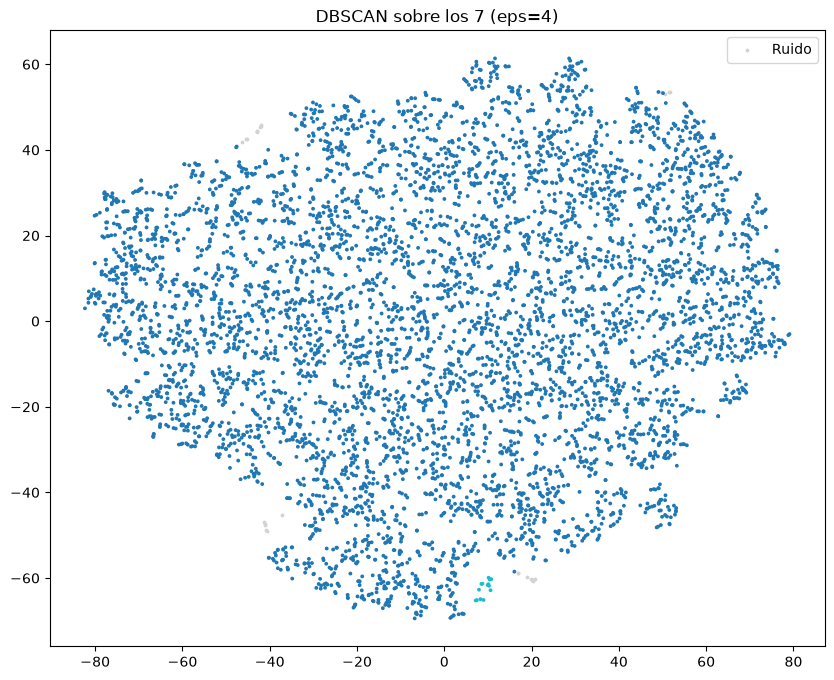

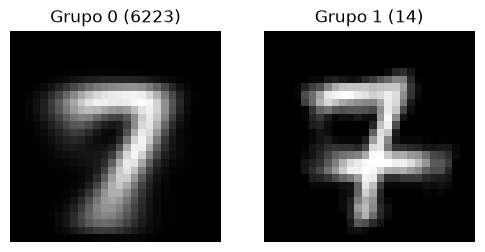

In [37]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Probar varios eps para ver cuál da resultados razonables
for eps in [1, 2, 3, 4, 5, 7]:
    lab = DBSCAN(eps=eps, min_samples=10).fit_predict(X_7_tsne)
    n_grupos = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"eps={eps}: {n_grupos} grupos, {(lab == -1).sum()} ruido")

# 2. Elegir un eps y aplicar DBSCAN
eps = 4
labels_db = DBSCAN(eps=eps, min_samples=10).fit_predict(X_7_tsne)

# Grupos reales (sin contar el ruido, que es -1)
grupos = sorted(set(labels_db) - {-1})
k_db = len(grupos)
print("Grupos encontrados:", k_db)

# 3. Graficar el mapa (ruido en gris)
plt.figure(figsize=(10, 8))
ruido = labels_db == -1
plt.scatter(X_7_tsne[ruido, 0], X_7_tsne[ruido, 1], c="lightgray", s=3, label="Ruido")
plt.scatter(X_7_tsne[~ruido, 0], X_7_tsne[~ruido, 1], c=labels_db[~ruido], cmap="tab10", s=3)
plt.legend()
plt.title(f"DBSCAN sobre los 7 (eps={eps})")
plt.show()

# 4. 7 promedio de cada grupo (solo si hay al menos 1 grupo)
X_7_raw = X[mask].values

if k_db > 0:
    fig, axes = plt.subplots(1, k_db, figsize=(3*k_db, 3), squeeze=False)
    for ax, c in zip(axes[0], grupos):
        ax.imshow(X_7_raw[labels_db == c].mean(axis=0).reshape(28, 28), cmap="gray")
        ax.set_title(f"Grupo {c} ({(labels_db == c).sum()})")
        ax.axis("off")
    plt.show()

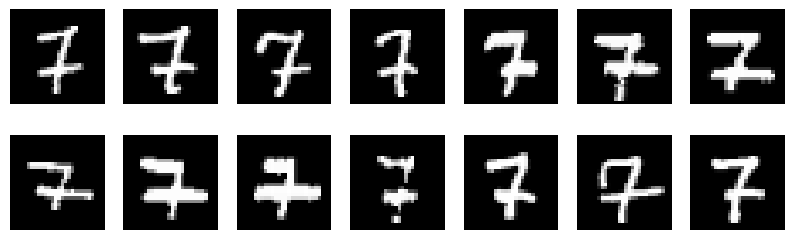

In [38]:
lab = DBSCAN(eps=4, min_samples=10).fit_predict(X_7_tsne)
ids = np.where(lab == 1)[0]

fig, axes = plt.subplots(2, 7, figsize=(10, 3))
for ax, i in zip(axes.ravel(), ids):
    ax.imshow(X_7_raw[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.show()